In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

# aesthetics
import seaborn as sns
sns.set_theme(style="whitegrid")

In [3]:
# using max uploaded KNN version for imputaiton 
# kept deaths, discuss in report
data_path = '/Users/yasminetani/Desktop/git/Myocardial-Infarction-ML-Project/Finalized_Feature_Sets/model_data_knn.parquet'
df = pd.read_parquet(data_path)

print(f"Dataset Shape: {df.shape}")
print(f"Target Distribution (ZSN):\n{df['ZSN'].value_counts(normalize=True)}")

# first few rows
df.head()

Dataset Shape: (1700, 31)
Target Distribution (ZSN):
ZSN
0    0.768235
1    0.231765
Name: proportion, dtype: float64


,ZSN,train_dummy,AGE,SEX,INF_ANAM,IBS_POST,GB,endocr_01,S_AD_ORIT,D_AD_ORIT,...,any_arrhythmia,any_conduction_block,ROE_log,ALT_BLOOD_log,AST_BLOOD_log,ZSN_A_recode,time_bin,angina_timing,angina_severity,htn_duration
0,0,0,77.0,1.0,2.0,2.0,3.0,0.0,180.0,100.0,...,1.0,1.0,2.833213,0.370825,0.226692,none,intermediate,recent,other,long
1,0,1,55.0,1.0,1.0,0.0,0.0,0.0,120.0,90.0,...,1.0,0.0,1.386294,0.322083,0.165514,none,early,never,none,none
2,0,0,52.0,1.0,0.0,2.0,2.0,0.0,180.0,100.0,...,1.0,0.0,2.418427,0.262364,0.104360,none,early,never,none,short
3,1,1,68.0,0.0,0.0,2.0,2.0,0.0,120.0,70.0,...,0.0,0.0,2.418427,0.559616,0.314811,mild,early,never,none,short
4,0,0,60.0,1.0,0.0,2.0,3.0,0.0,160.0,90.0,...,0.0,0.0,2.418427,0.371564,0.198851,none,late,never,none,long


In [4]:
target_col = 'ZSN'

X = df.drop(columns=[target_col])
y = df[target_col]

# data splitttt
# used same random seed as max
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=321, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1360
Testing samples: 340


In [5]:
# intialize model vibes
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    enable_categorical=True, 
    tree_method='hist', # Required for enable_categorical=True
    eval_metric='logloss'
)

# model fitting
model.fit(X_train, y_train)

# predictions
y_probs = model.predict_proba(X_test)[:, 1]
y_preds = model.predict(X_test)

XGBoost Test AUC: 0.6347

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       261
           1       0.66      0.24      0.35        79

    accuracy                           0.79       340
   macro avg       0.73      0.60      0.61       340
weighted avg       0.77      0.79      0.76       340



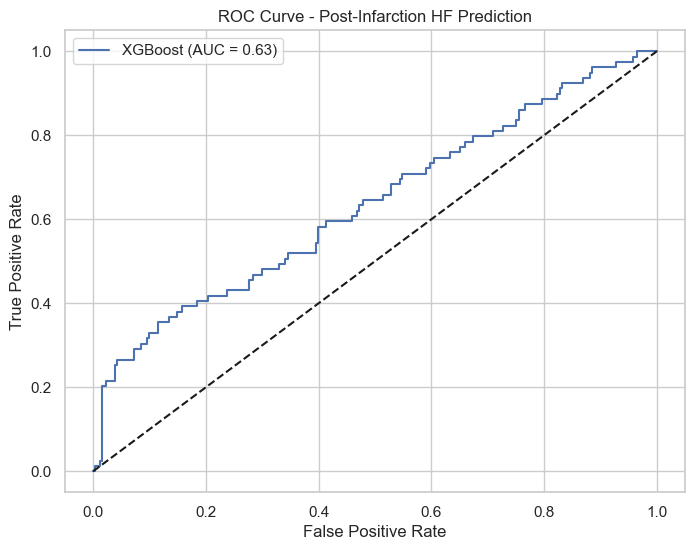

In [6]:
auc_score = roc_auc_score(y_test, y_probs)
print(f"XGBoost Test AUC: {auc_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_preds))

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Post-Infarction HF Prediction')
plt.legend()
plt.show()

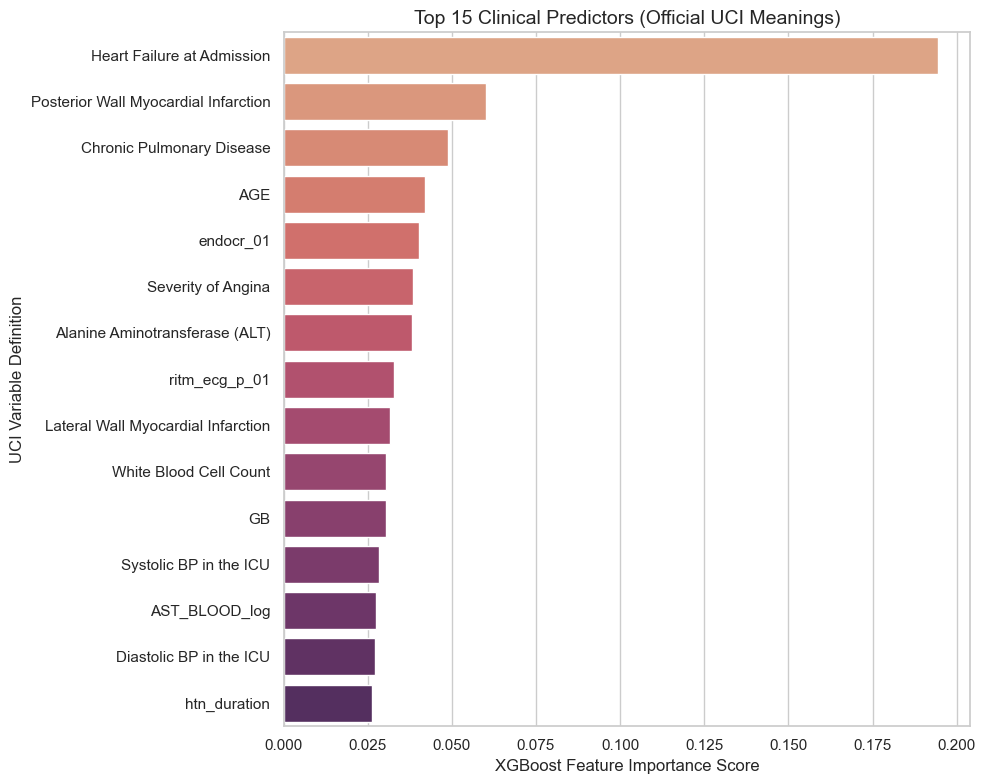

In [7]:
# defs for ORIT and History variables in data
uci_final_map = {
    # vitals
    "S_AD_ORIT": "Systolic BP in the ICU",
    "D_AD_ORIT": "Diastolic BP in the ICU",
    "angina_severity": "Severity of Angina",
    
    # history
    "any_pulmonary_disease": "Chronic Pulmonary Disease",
    "any_endocr_disease": "Endocrine Disease History",
    "any_renal_disease": "Chronic Renal Failure",
    "any_liver_disease": "Liver or Biliary Disease",
    "SIM_GIPER": "Hyperlipoproteinemia (High Cholesterol)",
    "GBK": "Heredity of Ischemic Heart Disease",
    
    # lab work
    "ROE": "Erythrocyte Sedimentation Rate (ESR)",
    "L_BLOOD": "White Blood Cell Count",
    "ALT_BLOOD": "Alanine Aminotransferase (ALT)",
    "K_SH_POST": "Cardiogenic Shock",
    "ZSN_A": "Heart Failure at Admission",
    
    # infarct locations
    "ant_im": "Anterior Wall Myocardial Infarction",
    "lat_im": "Lateral Wall Myocardial Infarction",
    "inf_im": "Inferior Wall Myocardial Infarction",
    "post_im": "Posterior Wall Myocardial Infarction",
    "age": "Patient Age"
}

# importance
df_importance = pd.DataFrame({
    'Code': X_train.columns,
    'Score': model.feature_importances_
})

# literal definitions
def literal_map(code):
    # find the root variable name
    base = code.replace('_01', '').replace('_log', '').replace('_recode', '')
    # Return the literal definition or the code if it's missing
    return uci_final_map.get(base, code)

df_importance['Clinical_Definition'] = df_importance['Code'].apply(literal_map)

# sort & plot
df_importance = df_importance.sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Score', 
    y='Clinical_Definition', 
    data=df_importance.head(15), 
    palette='flare'
)

plt.title('Top 15 Clinical Predictors (Official UCI Meanings)', fontsize=14)
plt.xlabel('XGBoost Feature Importance Score')
plt.ylabel('UCI Variable Definition')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import roc_curve
import numpy as np

# 1. Get probabilities from your XGBoost model on the TRAINING set
# (Assuming your model is named 'model' and your training data is 'X_train')
y_train_prob = model.predict_proba(X_train)[:, 1]

# 2. Calculate the ROC curve points
fpr, tpr, roc_thresholds = roc_curve(y_train, y_train_prob)

# 3. Find the threshold that hits EXACTLY 80% Recall with the lowest False Positives
desired_recall = 0.80
valid_idx = np.where(tpr >= desired_recall)[0]
best_idx = valid_idx[np.argmin(fpr[valid_idx])]

my_chosen_threshold = roc_thresholds[best_idx]

print(f"My XGBoost Threshold: {my_chosen_threshold:.4f}")
print(f"Actual Recall at this threshold: {tpr[best_idx]:.4f}")
print(f"False Positive Rate at this threshold: {fpr[best_idx]:.4f}")

My XGBoost Threshold: 0.2968
Actual Recall at this threshold: 0.8000
False Positive Rate at this threshold: 0.0536


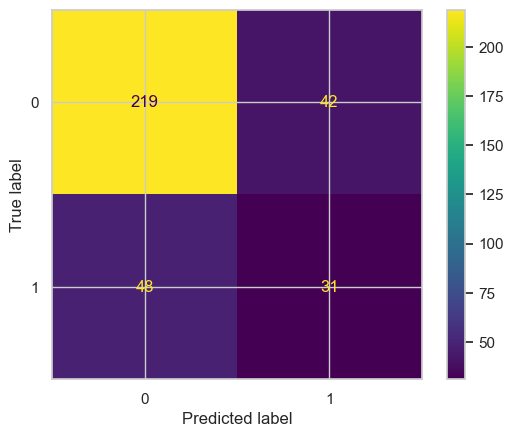

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Apply the threshold to your test probabilities
y_pred_threshold = (model.predict_proba(X_test)[:, 1] >= 0.2968).astype(int)
cm = confusion_matrix(y_test, y_pred_threshold)
ConfusionMatrixDisplay(cm).plot()

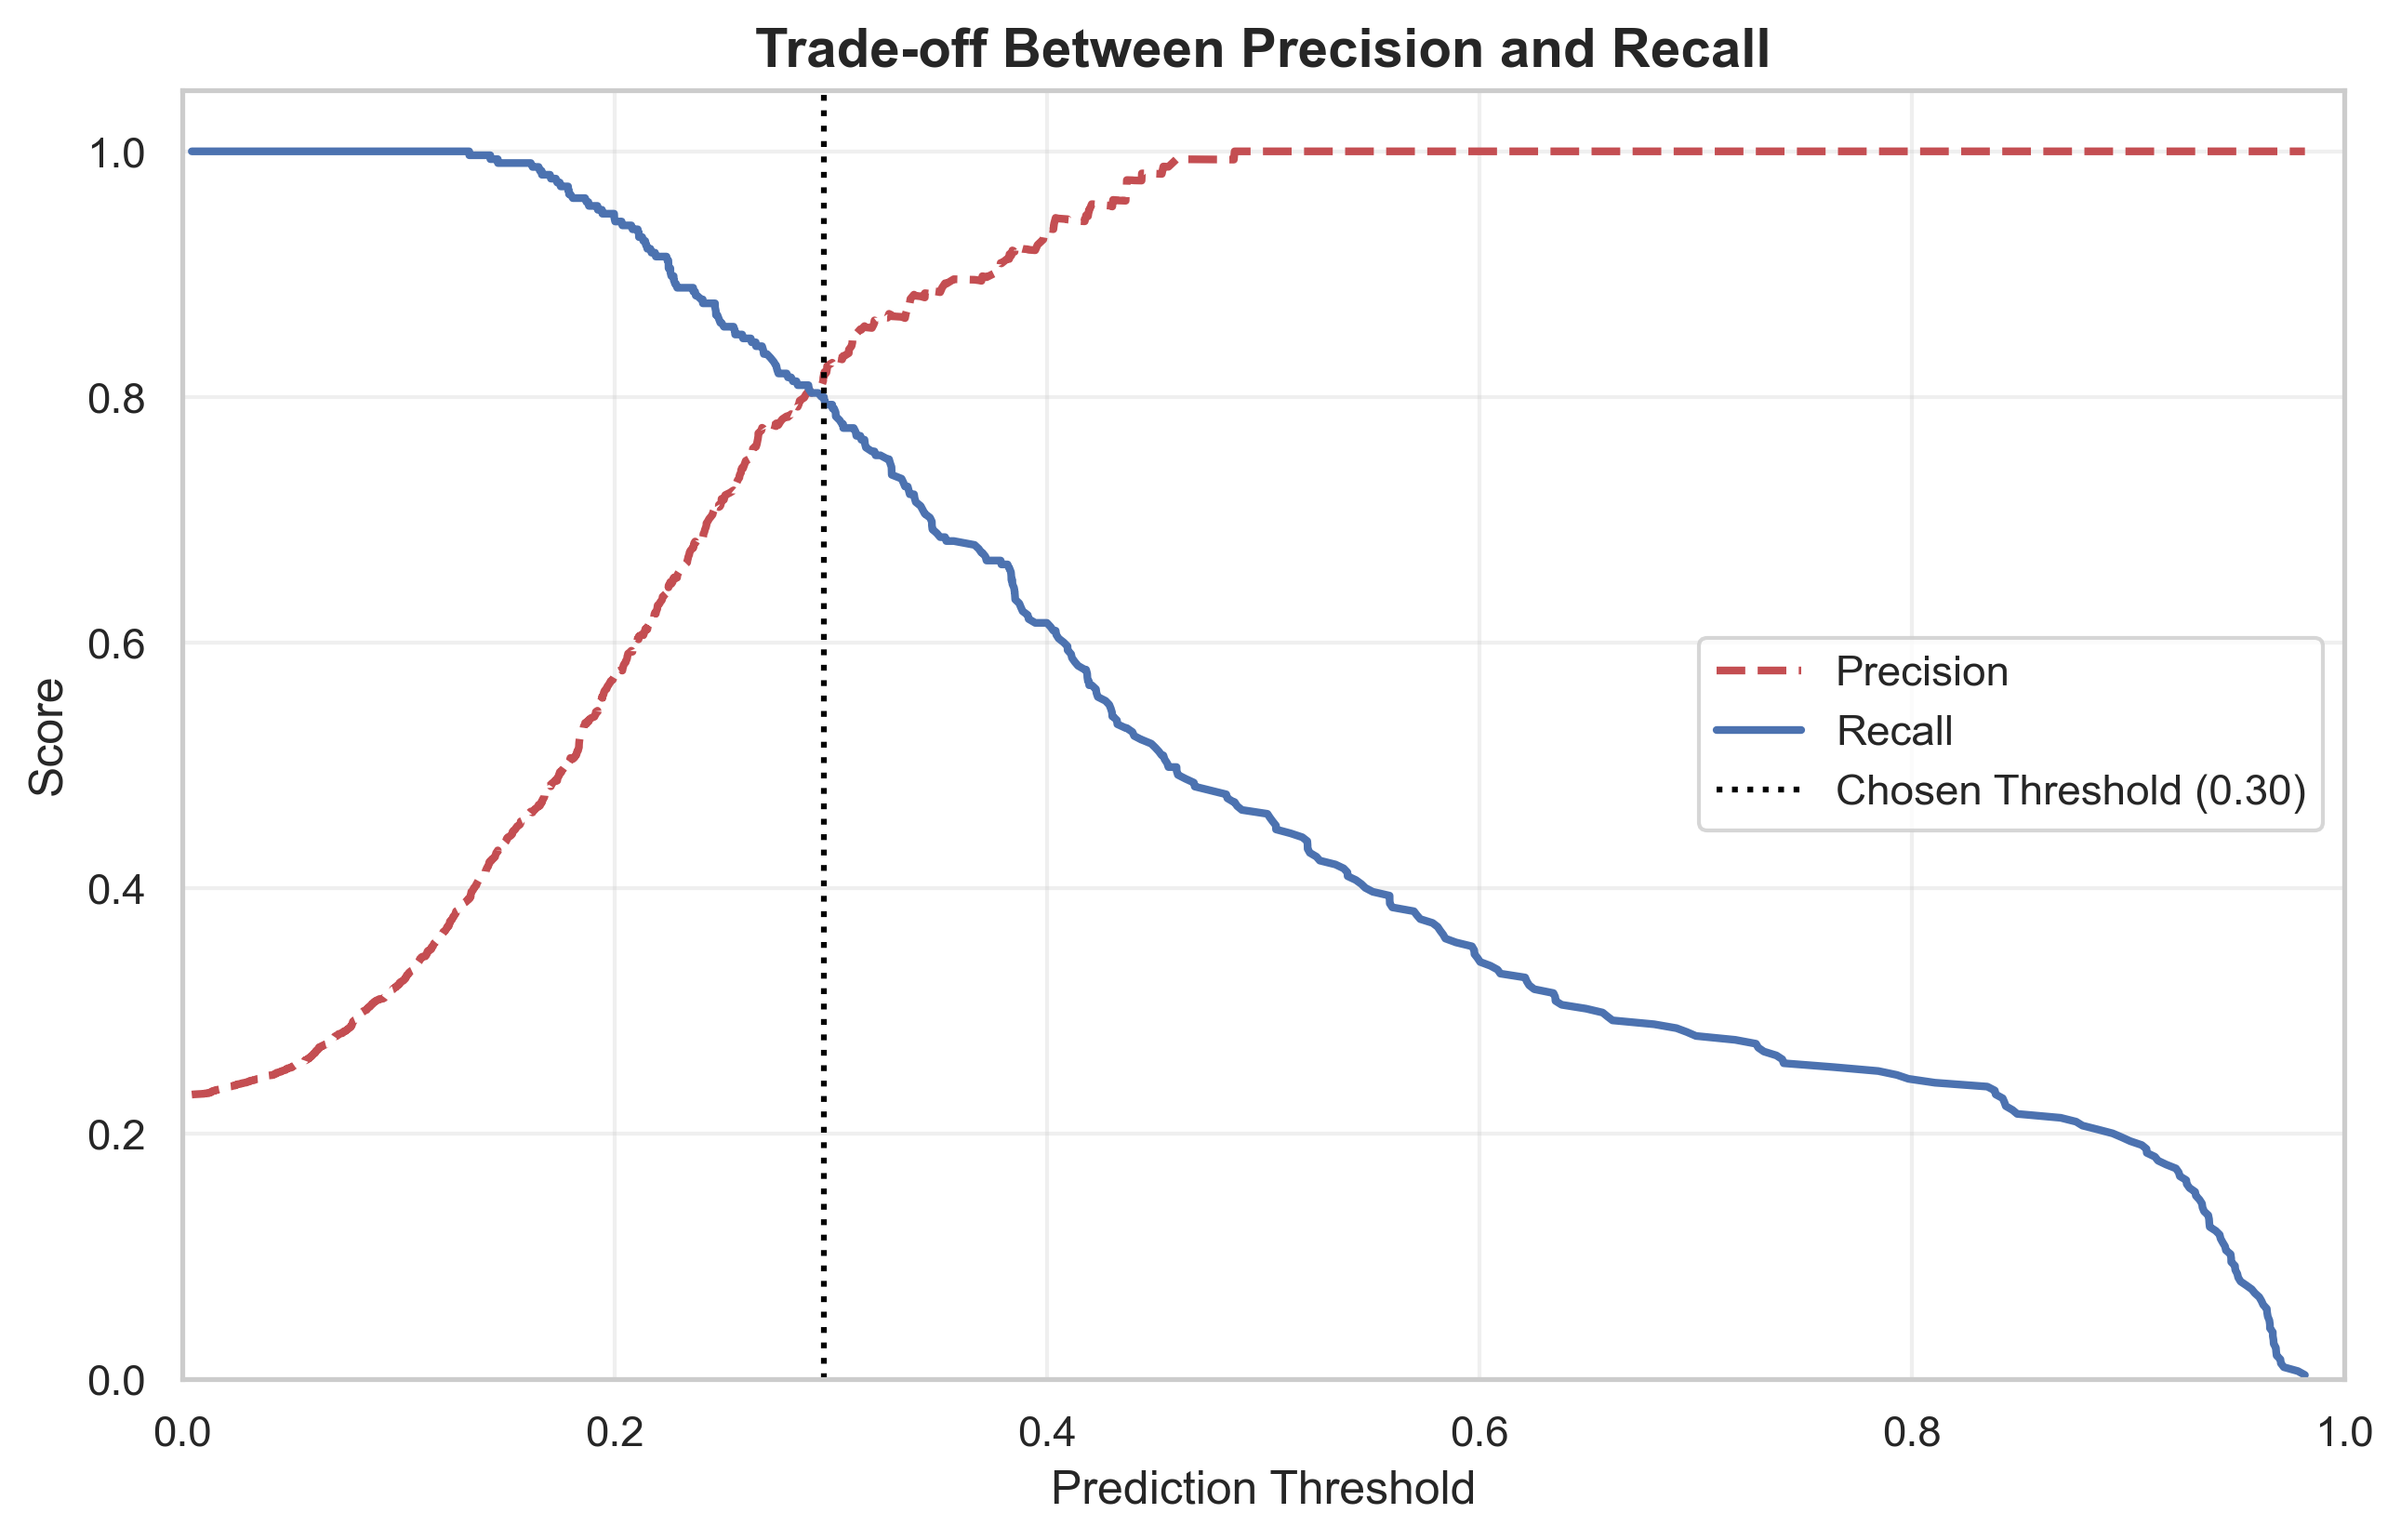

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

#  precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_train, y_train_prob)

# plot
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(thresholds, precision[:-1], 'r--', label='Precision', linewidth=2)
plt.plot(thresholds, recall[:-1], 'b-', label='Recall', linewidth=2)

# vertical line for my threshold (0.2968)
plt.axvline(x=0.2968, color='black', linestyle=':', label='Chosen Threshold (0.30)')

# aesthetics!
plt.title('Trade-off Between Precision and Recall', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.savefig('clean_threshold_plot.png', bbox_inches='tight')
plt.show()

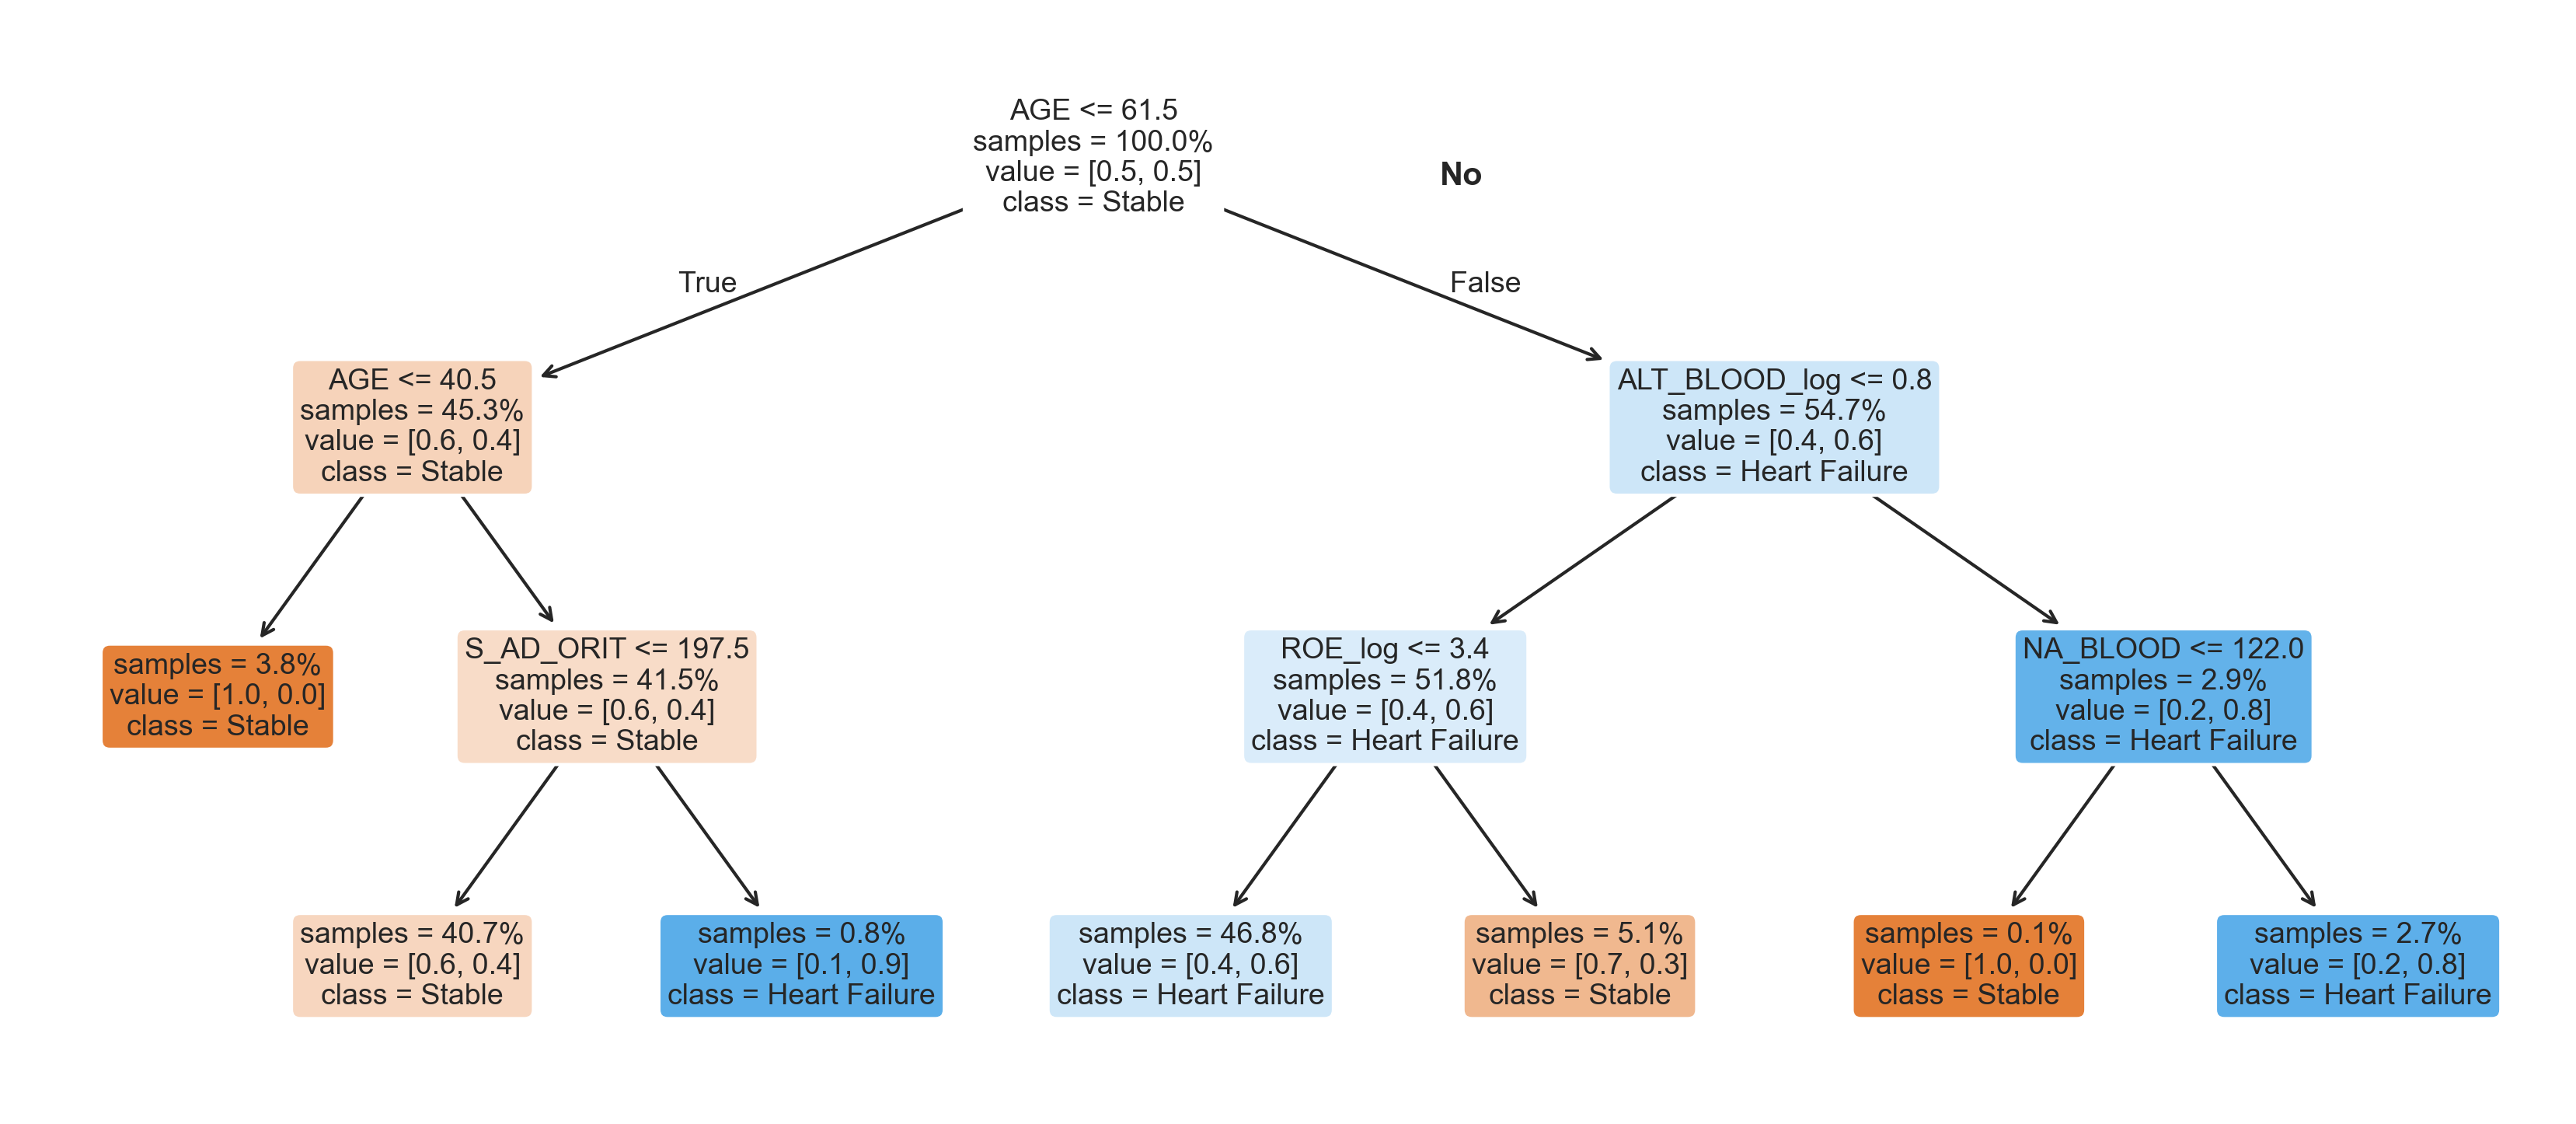

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# version of the data without the 'none' strings for the visual
X_train_visual = X_train.select_dtypes(exclude=['object', 'category'])

# train dt for prof. figure
dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt.fit(X_train_visual, y_train)

# plot
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

plot_tree(dt, 
          feature_names=X_train_visual.columns, 
          class_names=['Stable', 'Heart Failure'], 
          filled=True, 
          rounded=True,
          impurity=False, 
          proportion=True, 
          precision=1, 
          fontsize=9,
          ax=ax)

# aesthetics
ax.text(0.42, 0.85, 'Yes', transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.56, 0.85, 'No', transform=ax.transAxes, fontsize=10, fontweight='bold')

plt.axis('off')
plt.savefig('final_professional_tree.png', bbox_inches='tight', pad_inches=0.05)
plt.show()